<div style='background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 12px; text-align: center; margin-bottom: 20px;'>
  <h1 style='color: #e94560; font-size: 42px; font-weight: bold; margin: 0 0 10px 0;'>Real Estate Price Prediction</h1>
  <h3 style='color: #a8dadc; font-size: 22px; font-weight: normal; margin: 0 0 20px 0;'>Log-Linear Regression Model &nbsp;|&nbsp; Machine Learning</h3>
  <p style='color: #ccc; font-size: 15px; margin: 0;'>
    <b style='color:#e94560;'>Dataset:</b> 5,000 properties — Rio de Janeiro, Brazil &nbsp;|&nbsp;
    <b style='color:#e94560;'>Tools:</b> Python · pandas · scikit-learn · statsmodels · seaborn
  </p>
</div>

# <font color='red' style='font-size: 30px;'>1.1 Exploring the Dataset</font>
<hr style='border: 2px solid red;'>

## Importing the pandas library

https://pandas.pydata.org/

In [1]:
import pandas as pd

## The Dataset and the Project
<hr>

### Description:
<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify; text-indent: 35px;'>The real estate market has been the subject of numerous studies and research in recent years. The financial crisis affecting the economy has significantly impacted investments and returns from this sector. This scenario drives increasing interest in demand forecasting studies based on characteristics of the market, the properties, and their surroundings.</p>

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify; text-indent: 35px;'>In this context, the main objective of this project is to develop a real estate valuation system using the <b>log-linear regression</b> methodology — one of the core techniques in machine learning.</p>

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify; text-indent: 35px;'>The <b>dataset</b> is a random sample of <b>5,000 properties</b> available for sale in the city of <b>Rio de Janeiro, Brazil</b>.</p>

### Features:
<ul style='font-size: 18px; line-height: 2; text-align: justify;'>
    <li><b>Price</b> — Listing price (R$) of the property</li>
    <li><b>Area</b> — Property area in m²</li>
    <li><b>Dist_Beach</b> — Straight-line distance from the property to the beach (km)</li>
    <li><b>Dist_Pharmacy</b> — Straight-line distance from the property to the nearest pharmacy (km)</li>
</ul>

## Loading the data

In [2]:
df = pd.read_csv('./Data/dataset.csv', sep=';')

## Previewing the data

In [3]:
df.head()

,Price,Area,Dist_Beach,Dist_Pharmacy
0,4600000,280,0.240925,0.793637
1,900000,208,0.904136,0.134494
2,2550000,170,0.059525,0.423318
3,550000,100,2.883181,0.525064
4,2200000,164,0.239758,0.192374


## Checking the dataset size

In [4]:
df.shape

(5000, 4)

# <font color='red' style='font-size: 30px;'>1.2 Preliminary Analysis</font>
<hr style='border: 2px solid red;'>

## Descriptive statistics

In [5]:
df.describe().round(2)

,Price,Area,Dist_Beach,Dist_Pharmacy
count,5000.00,5000.00,5000.00,5000.00
mean,1402926.39,121.94,3.02,0.50
std,1883268.85,90.54,3.17,0.29
min,75000.00,16.00,0.00,0.00
25%,460000.00,70.00,0.44,0.24
50%,820000.00,93.00,1.48,0.50
75%,1590000.00,146.00,5.61,0.75
max,25000000.00,2000.00,17.96,1.00


## Correlation matrix

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>The <b>correlation coefficient</b> is a measure of linear association between two variables, ranging from <b>-1</b> to <b>+1</b>: <b>-1</b> indicates a perfect negative association and <b>+1</b> indicates a perfect positive association.</p>

In [6]:
df.corr().round(4)

,Price,Area,Dist_Beach,Dist_Pharmacy
Price,1.0000,0.7110,-0.3665,-0.0244
Area,0.7110,1.0000,-0.2834,-0.0310
Dist_Beach,-0.3665,-0.2834,1.0000,0.0256
Dist_Pharmacy,-0.0244,-0.0310,0.0256,1.0000


# <font color='red' style='font-size: 30px;'>2.1 Behavior of the Dependent Variable (Y)</font>
<hr style='border: 2px solid red;'>

## Importing the seaborn library
https://seaborn.pydata.org/
<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>Seaborn is a Python data visualization library built on top of matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.</p>

In [7]:
import seaborn as sns

## Chart formatting settings

In [8]:
# palette -> Accent, Accent_r, Blues, Blues_r, BrBG, BrBG_r, BuGn, BuGn_r, BuPu, BuPu_r, CMRmap, CMRmap_r, Dark2, Dark2_r, GnBu, GnBu_r, Greens, Greens_r, Greys, Greys_r, OrRd, OrRd_r, Oranges, Oranges_r, PRGn, PRGn_r, Paired, Paired_r, Pastel1, Pastel1_r, Pastel2, Pastel2_r, PiYG, PiYG_r, PuBu, PuBuGn, PuBuGn_r, PuBu_r, PuOr, PuOr_r, PuRd, PuRd_r, Purples, Purples_r, RdBu, RdBu_r, RdGy, RdGy_r, RdPu, RdPu_r, RdYlBu, RdYlBu_r, RdYlGn, RdYlGn_r, Reds, Reds_r, Set1, Set1_r, Set2, Set2_r, Set3, Set3_r, Spectral, Spectral_r, Wistia, Wistia_r, YlGn, YlGnBu, YlGnBu_r, YlGn_r, YlOrBr, YlOrBr_r, YlOrRd, YlOrRd_r, afmhot, afmhot_r, autumn, autumn_r, binary, binary_r, bone, bone_r, brg, brg_r, bwr, bwr_r, cividis, cividis_r, cool, cool_r, coolwarm, coolwarm_r, copper, copper_r, cubehelix, cubehelix_r, flag, flag_r, gist_earth, gist_earth_r, gist_gray, gist_gray_r, gist_heat, gist_heat_r, gist_ncar, gist_ncar_r, gist_rainbow, gist_rainbow_r, gist_stern, gist_stern_r, gist_yarg, gist_yarg_r, gnuplot, gnuplot2, gnuplot2_r, gnuplot_r, gray, gray_r, hot, hot_r, hsv, hsv_r, icefire, icefire_r, inferno, inferno_r, jet, jet_r, magma, magma_r, mako, mako_r, nipy_spectral, nipy_spectral_r, ocean, ocean_r, pink, pink_r, plasma, plasma_r, prism, prism_r, rainbow, rainbow_r, rocket, rocket_r, seismic, seismic_r, spring, spring_r, summer, summer_r, tab10, tab10_r, tab20, tab20_r, tab20b, tab20b_r, tab20c, tab20c_r, terrain, terrain_r, viridis, viridis_r, vlag, vlag_r, winter, winter_r
sns.set_palette('rocket')
# style -> white, dark, whitegrid, darkgrid, ticks
sns.set_style('darkgrid')

## Box plot of the *dependent* variable (y)

<Axes: title={'center': 'Property Prices'}, xlabel='BRL (R$)'>

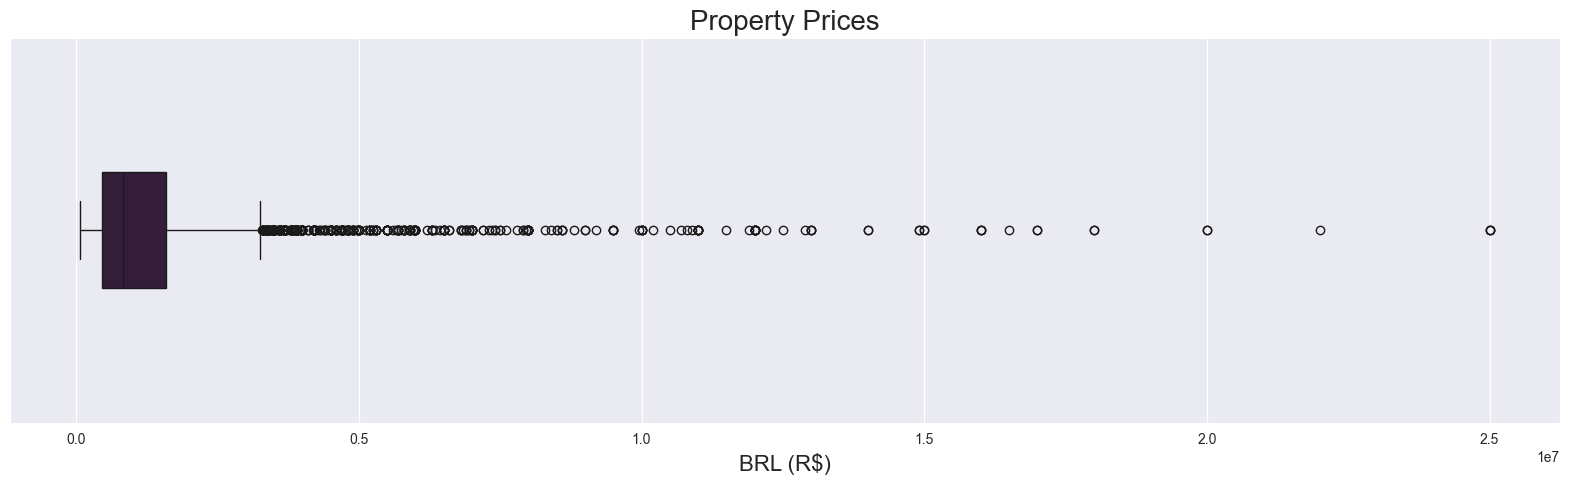

In [9]:
ax = sns.boxplot(data=df['Price'], orient='h', width=0.3)
ax.figure.set_size_inches(20, 5)
ax.set_title('Property Prices', fontsize=20)
ax.set_xlabel('BRL (R$)', fontsize=16)
ax

# <font color='red' style='font-size: 30px;'>2.2 Frequency Distribution</font>
<hr style='border: 2px solid red;'>

## Frequency distribution of the *dependent* variable (y)

C:\Users\jeanl\AppData\Local\Temp\ipykernel_1348\1819253624.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(df['Price'])


<Axes: title={'center': 'Frequency Distribution'}, xlabel='Property Price (R$)', ylabel='Density'>

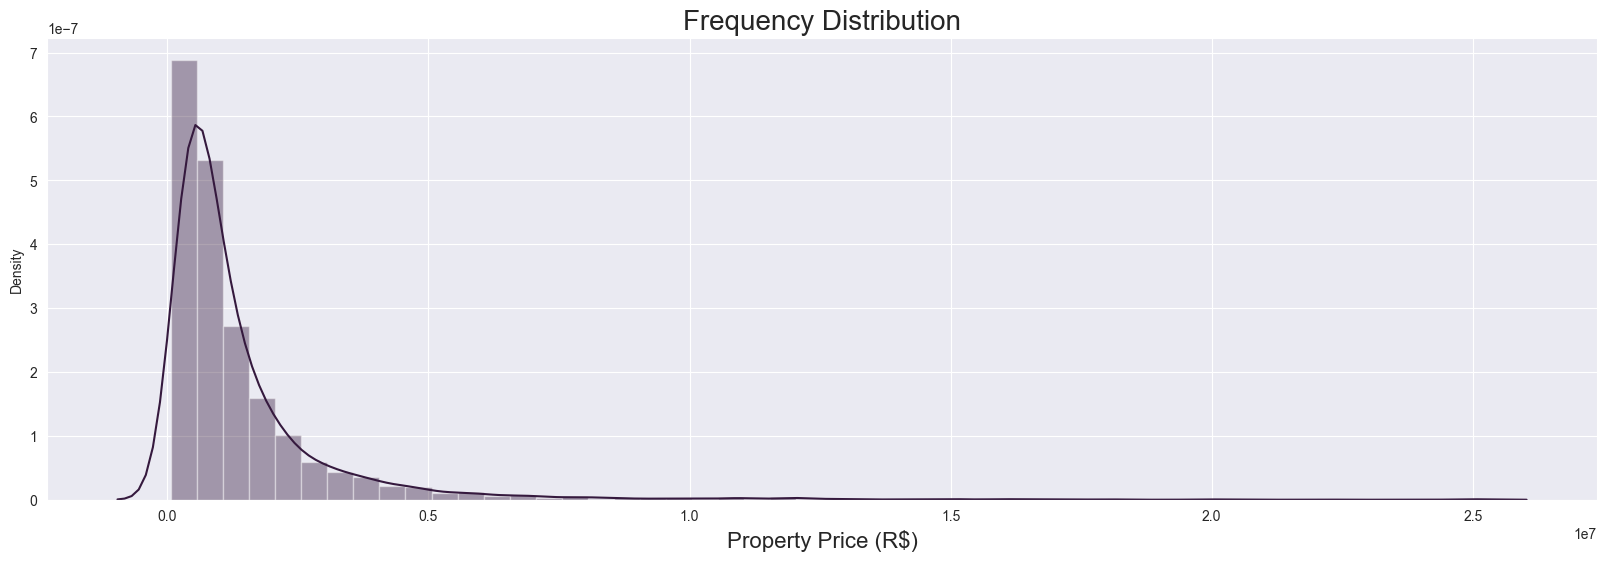

In [10]:
ax = sns.distplot(df['Price'])
ax.figure.set_size_inches(20, 6)
ax.set_title('Frequency Distribution', fontsize=20)
ax.set_xlabel('Property Price (R$)', fontsize=16)
ax

# <font color='red' style='font-size: 30px;'>2.3 Scatter Plots Between Variables</font>
<hr style='border: 2px solid red;'>

## Pairwise scatter plots between dataset variables

## seaborn.pairplot

https://seaborn.pydata.org/generated/seaborn.pairplot.html?highlight=pairplot#seaborn.pairplot

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>Plots pairwise relationships across variables in a dataset.</p>

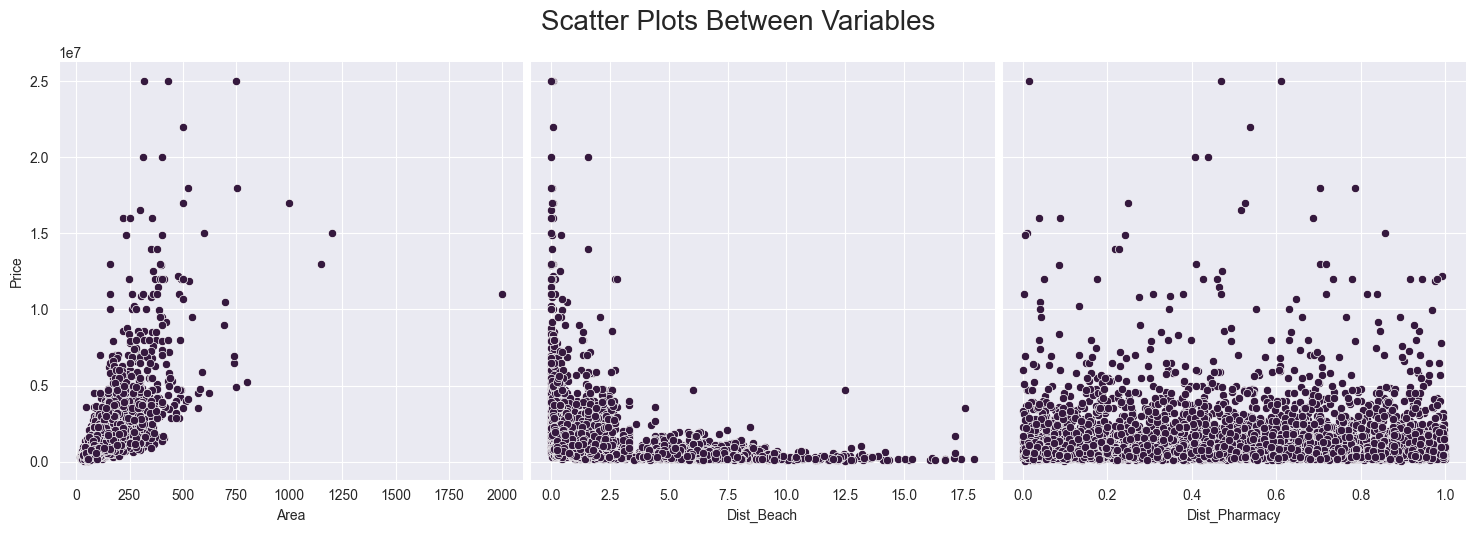

In [11]:
ax = sns.pairplot(data=df, y_vars='Price', x_vars=['Area', 'Dist_Beach', 'Dist_Pharmacy'], height=5)
ax.figure.suptitle('Scatter Plots Between Variables', fontsize=20, y=1.05)
ax

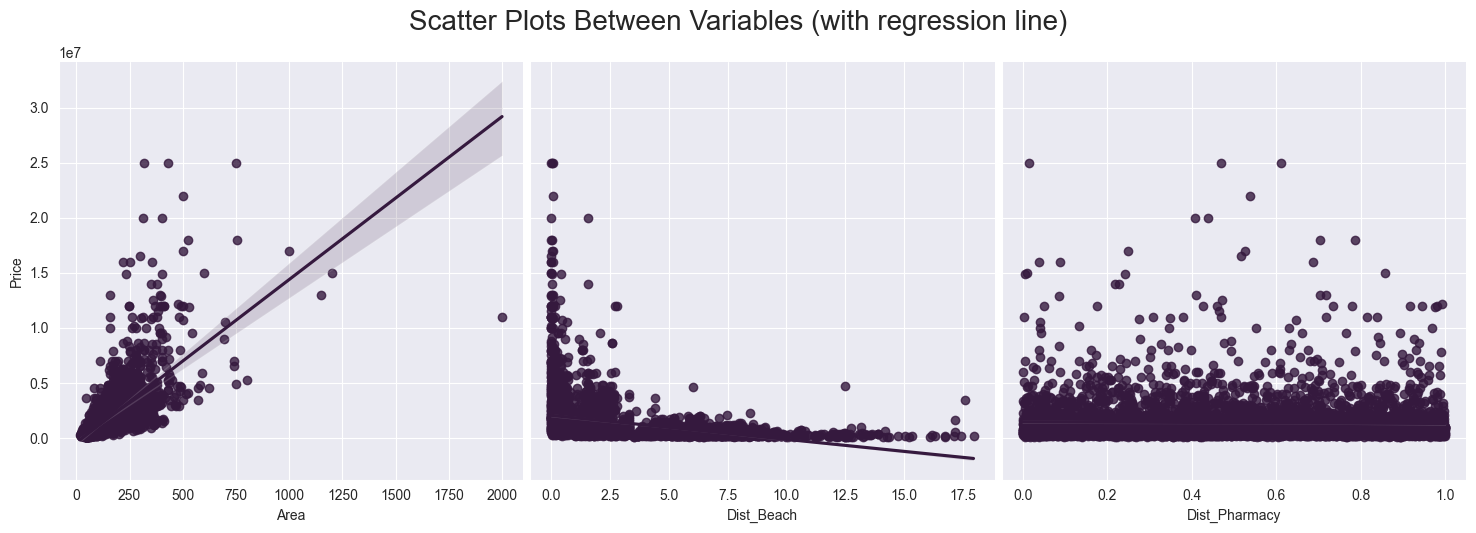

In [12]:
ax = sns.pairplot(data=df, y_vars='Price', x_vars=['Area', 'Dist_Beach', 'Dist_Pharmacy'], height=5, kind='reg')
ax.figure.suptitle('Scatter Plots Between Variables (with regression line)', fontsize=20, y=1.05)
ax

# <font color='red' style='font-size: 30px;'>3.1 Transforming the Data</font>
<hr style='border: 2px solid red;'>

## Normal Distribution
<hr>

### Why normalize? 
<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>Parametric tests assume that sample data were collected from a population with a known probability distribution. Most statistical tests assume that data follow a normal distribution (Student's t-test, confidence intervals, etc.).</p>

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>Since the raw <b>Price</b> distribution is right-skewed, we apply a <b>logarithmic transformation</b> to all variables to achieve approximate normality and meet linear regression assumptions.</p>

## Importing the numpy library

In [13]:
import numpy as np

## Applying log transformation to the dataset variables

https://docs.scipy.org/doc/numpy-1.15.0/reference/generated/numpy.log.html

In [14]:
df['log_Price'] = np.log(df['Price'])
df['log_Area'] = np.log(df['Area'])
df['log_Dist_Beach'] = np.log(df['Dist_Beach'] + 1)
df['log_Dist_Pharmacy'] = np.log(df['Dist_Pharmacy'] + 1)

In [15]:
df.head()

,Price,Area,Dist_Beach,Dist_Pharmacy,log_Price,log_Area,log_Dist_Beach,log_Dist_Pharmacy
0,4600000,280,0.240925,0.793637,15.341567,5.634790,0.215857,0.584245
1,900000,208,0.904136,0.134494,13.710150,5.337538,0.644028,0.126187
2,2550000,170,0.059525,0.423318,14.751604,5.135798,0.057821,0.352991
3,550000,100,2.883181,0.525064,13.217674,4.605170,1.356655,0.422036
4,2200000,164,0.239758,0.192374,14.603968,5.099866,0.214916,0.175946


## Frequency distribution of the *transformed* dependent variable (y)

<Axes: title={'center': 'Frequency Distribution (after log transformation)'}, xlabel='log of Property Price', ylabel='Count'>

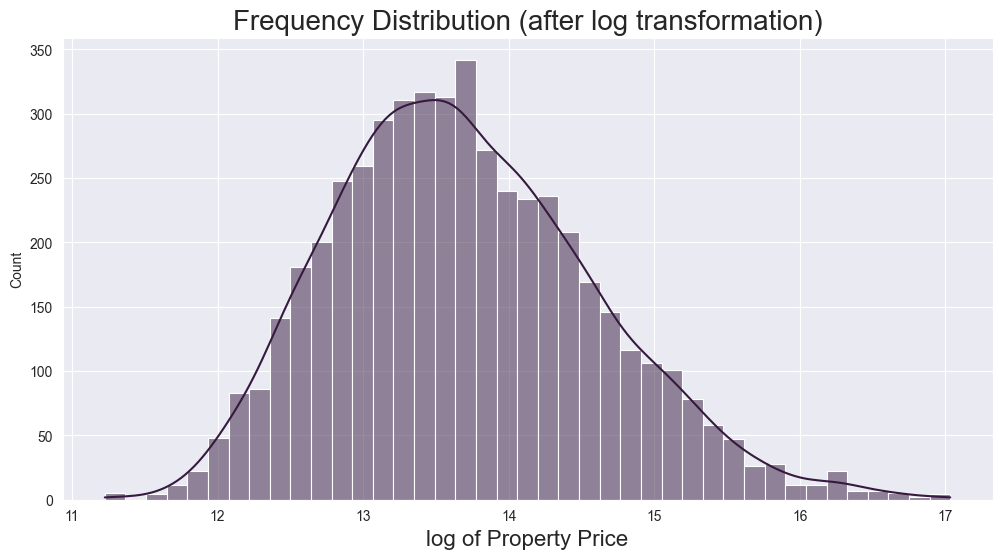

In [55]:
ax = sns.histplot(df['log_Price'], kde=True)
ax.figure.set_size_inches(12, 6)
ax.set_title('Frequency Distribution (after log transformation)', fontsize=20)
ax.set_xlabel('log of Property Price', fontsize=16)
ax

# <font color='red' style='font-size: 30px;'>3.2 Verifying Linear Relationships</font>
<hr style='border: 2px solid red;'>

## Scatter plots between the transformed dataset variables

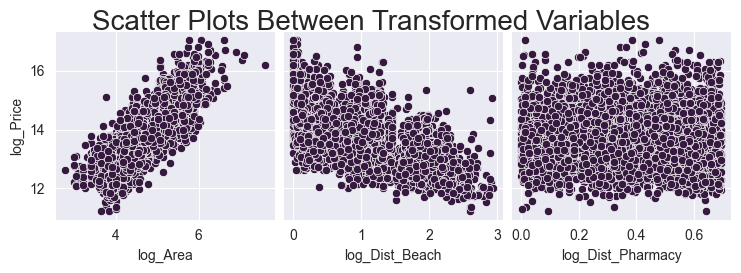

In [17]:
ax = sns.pairplot(data=df, y_vars='log_Price', x_vars=['log_Area', 'log_Dist_Beach', 'log_Dist_Pharmacy'])
ax.fig.suptitle('Scatter Plots Between Transformed Variables', fontsize=20, y=1.05)
ax

# <font color='red' style='font-size: 30px;'>4.1 Creating Train and Test Datasets</font>
<hr style='border: 2px solid red;'>

## Importing *train_test_split* from *scikit-learn*

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [18]:
from sklearn.model_selection import train_test_split

## Creating a pandas Series to store Property Prices (y)

In [19]:
y = df['log_Price']

## Creating a pandas DataFrame to store the explanatory variables (X)

In [20]:
X = df[['log_Area', 'log_Dist_Beach', 'log_Dist_Pharmacy']]

## Splitting into train and test sets

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2811)

# Linear Regression
<hr>

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>Regression analysis studies the dependence of one variable (the <b>dependent</b> variable) on one or more explanatory variables, with the goal of estimating and/or predicting the average value of the former given known values of the latter.</p>


## scikit-learn (https://scikit-learn.org/stable/)

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'><em>scikit-learn</em> is a Python module specialized in <em>machine learning</em> solutions, providing simple and efficient tools for data mining and data analysis.</p>

## Importing the statsmodels library

https://www.statsmodels.org/stable/index.html

In [22]:
import statsmodels.api as sm

## Fitting the model with statsmodels

In [23]:
X_train_const = sm.add_constant(X_train)

In [24]:
X_train_const

,const,log_Area,log_Dist_Beach,log_Dist_Pharmacy
2661,1.0,5.945421,0.000000,0.382273
912,1.0,3.135494,0.972865,0.605015
3042,1.0,4.317488,1.794961,0.486594
141,1.0,3.401197,0.310455,0.599609
3854,1.0,5.676754,0.032193,0.101903
...,...,...,...,...
3657,1.0,5.075174,2.023480,0.333605
979,1.0,4.174387,2.296141,0.156465
2389,1.0,4.394449,1.367741,0.409727
447,1.0,3.951244,2.166841,0.217381


In [25]:
model_sm = sm.OLS(y_train, X_train_const, hasconst=True).fit()

In [26]:
model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_Price   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     5495.
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        11:14:25   Log-Likelihood:                -2044.9
No. Observations:                4000   AIC:                             4098.
Df Residuals:                    3996   BIC:                             4123.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 9.3417      0.060    154.734      0.000       9.223       9.460
log_Area              1.0580      0.012     89.320      0.000       1.035       1.081
log_Dist_Beach       -0.4905      0.009    -56.690      0.000      -0.508      -0.474
log_Dist_Pharmacy    -0.0167      0.032     -0.521      0.603      -0.080       0.046
==============================================================================
Omnibus:                       64.751   Durbin-Watson:                   1.971
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              106.858
Skew:                           0.136   Prob(JB):                     6.25e-24
Kurtosis:                       3.753   Cond. No.                         47.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# <font color='red' style='font-size: 30px;'>4.2 Evaluating the Estimated Model</font>
<hr style='border: 2px solid red;'>

## Reviewing the model's statistical summary

In [27]:
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:              log_Price   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     5495.
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        11:14:45   Log-Likelihood:                -2044.9
No. Observations:                4000   AIC:                             4098.
Df Residuals:                    3996   BIC:                             4123.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 9.3417      0.06

# <font color='red' style='font-size: 30px;'>4.3 Refining the Model and Re-evaluating the Fit</font>
<hr style='border: 2px solid red;'>

## Redefining the explanatory variable set (X)

In [28]:
X = df[['log_Area', 'log_Dist_Beach']]

## Splitting into train and test sets

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2811)

## Fitting the refined model with statsmodels

In [30]:
X_train_const = sm.add_constant(X_train)

In [31]:
model_sm = sm.OLS(y_train, X_train_const, hasconst=True).fit()

## Reviewing the refined model's statistical summary

In [32]:
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:              log_Price   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     8244.
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        11:14:56   Log-Likelihood:                -2045.1
No. Observations:                4000   AIC:                             4096.
Df Residuals:                    3997   BIC:                             4115.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              9.3349      0.059    158.

# <font color='red' style='font-size: 30px;'>5.1 Fitting the Final Model with Training Data</font>
<hr style='border: 2px solid red;'>

## Importing *LinearRegression* and *metrics* from *scikit-learn*

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

https://scikit-learn.org/stable/modules/classes.html#regression-metrics

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## Instantiating the *LinearRegression()* class

In [34]:
model = LinearRegression()

## Training the model with the *fit()* method on TRAINING data (X_train, y_train)

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.fit

In [35]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## R² score on TRAINING data

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.score

### Coefficient of Determination — R²

The coefficient of determination (R²) is a summary measure indicating how well the regression line fits the data. It ranges from 0 to 1.

$$R^2(y, \hat{y}) = 1 - \frac {\sum_{i=0}^{n-1}(y_i-\hat{y}_i)^2}{\sum_{i=0}^{n-1}(y_i-\bar{y}_i)^2}$$

In [37]:
print(f'R² (train) -> {round(model.score(X_train, y_train), 3)}')

R² (train) -> 0.805


## Generating predictions for TEST data (X_test) using *predict()*

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.predict

In [38]:
y_pred = model.predict(X_test)

## R² score on TEST data (out-of-sample evaluation)

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html#sklearn.metrics.r2_score

In [40]:
print(f'R² (test)  -> {round(metrics.r2_score(y_test, y_pred), 3)}')

R² (test)  -> 0.79


# <font color='red' style='font-size: 30px;'>5.2 Generating Point Predictions</font>
<hr style='border: 2px solid red;'>

## Sample input from the test set

In [41]:
input_data = X_test[0:1]
input_data

,log_Area,log_Dist_Beach
1006,5.273,1.282769


## Generating a point prediction (log scale)

In [42]:
# Value is in log scale
model.predict(input_data)[0]

np.float64(14.28482006184788)

## Reversing the log transformation — converting back to R$

https://docs.scipy.org/doc/numpy-1.15.0/reference/generated/numpy.exp.html

In [43]:
np.exp(model.predict(input_data)[0])

np.float64(1598889.784779439)

## Interactive price simulator

In [44]:
area       = 150   # m²
dist_beach = 1     # km

sim_input = [[np.log(area), np.log(dist_beach + 1)]]
print(f'Estimated price: R$ {np.exp(model.predict(sim_input)[0]):,.2f}')

Estimated price: R$ 1,617,664.12


C:\Users\jeanl\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# <font color='red' style='font-size: 30px;'>5.3 Interpreting the Estimated Coefficients</font>
<hr style='border: 2px solid red;'>

## Model intercept

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>The <b>intercept</b> represents the average effect on $Y$ (Property Price) when all explanatory variables are excluded from the model. In the log-linear model, this coefficient must be exponentiated to be expressed in R$.</p>

In [45]:
model.intercept_

np.float64(9.334916409800318)

In [46]:
np.exp(model.intercept_)

np.float64(11326.68142806972)

## Regression slope coefficients

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>The <b>regression coefficients</b> $\beta_2$ and $\beta_3$ are known as <b>partial regression coefficients</b> or <b>partial slope coefficients</b>.</p>

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>A key feature of the log-linear model is that the slope coefficients measure <b>elasticities</b>: $\beta_i$ represents the expected percentage change in $Y$ for a 1% change in $X_i$, holding all other variables constant.</p>

In [47]:
model.coef_

array([ 1.05807818, -0.49061226])

## Confirming the order of explanatory variables in the DataFrame

In [48]:
X.columns

Index(['log_Area', 'log_Dist_Beach'], dtype='str')

## Creating the coefficient labels list

In [49]:
coef_index = ['log Intercept', 'log Area', 'log Distance to Beach']

## DataFrame of model coefficients

https://docs.scipy.org/doc/numpy/reference/generated/numpy.append.html?#numpy.append

In [50]:
pd.DataFrame(data=np.append(model.intercept_, model.coef_), index=coef_index, columns=['Parameters'])

,Parameters
log Intercept,9.334916
log Area,1.058078
log Distance to Beach,-0.490612


## Interpretation of the Estimated Coefficients

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>
<b>Intercept</b> → With all explanatory variables excluded ($X_2 = X_3 = 0$), the average baseline property price would be <b>R$ 11,326.68</b> (exp[9.334916]).
</p>

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>
<b>Area (m²)</b> → Holding distance to the beach constant ($X_3$), a <b>1% increase</b> in property area generates, on average, a <b>1.06% increase</b> in the property price.
</p>

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>
<b>Distance to the Beach (km)</b> → Holding area constant ($X_2$), a <b>1% increase</b> in the distance to the beach generates, on average, a <b>0.49% decrease</b> in the property price.
</p>

# <font color='red' style='font-size: 30px;'>5.4 Graphical Analysis of Model Results</font>
<hr style='border: 2px solid red;'>

## Generating predictions on TRAINING data

In [51]:
y_pred_train = model.predict(X_train)

## Scatter plot: predicted vs. actual values

https://seaborn.pydata.org/generated/seaborn.scatterplot.html

<Axes: title={'center': 'Predicted vs. Actual'}, xlabel='log Price — Predicted', ylabel='log Price — Actual'>

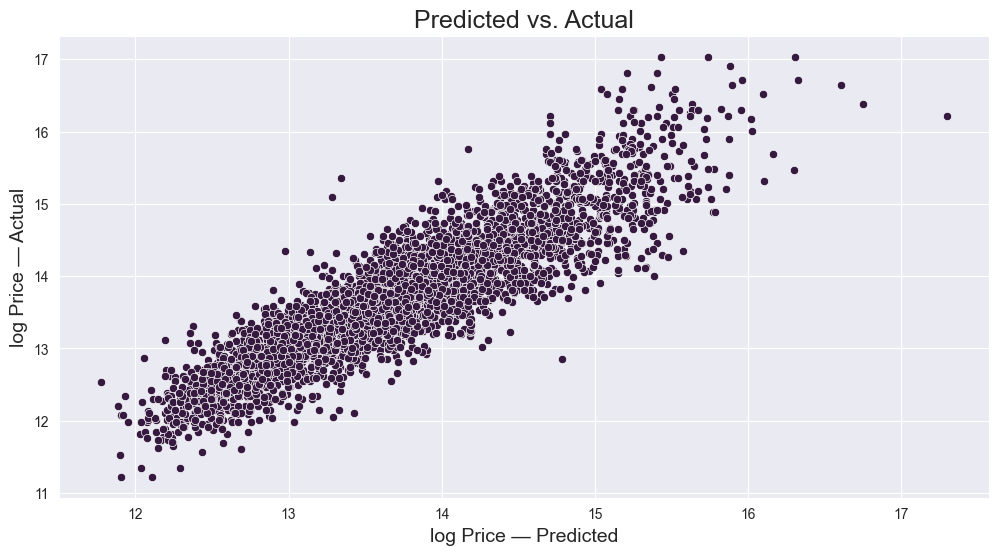

In [52]:
ax = sns.scatterplot(x=y_pred_train, y=y_train)
ax.figure.set_size_inches(12, 6)
ax.set_title('Predicted vs. Actual', fontsize=18)
ax.set_xlabel('log Price — Predicted', fontsize=14)
ax.set_ylabel('log Price — Actual', fontsize=14)
ax

## Computing residuals

In [53]:
residuals = y_train - y_pred_train

## Frequency distribution of residuals

<Axes: title={'center': 'Residuals — Frequency Distribution'}, xlabel='log Price', ylabel='Count'>

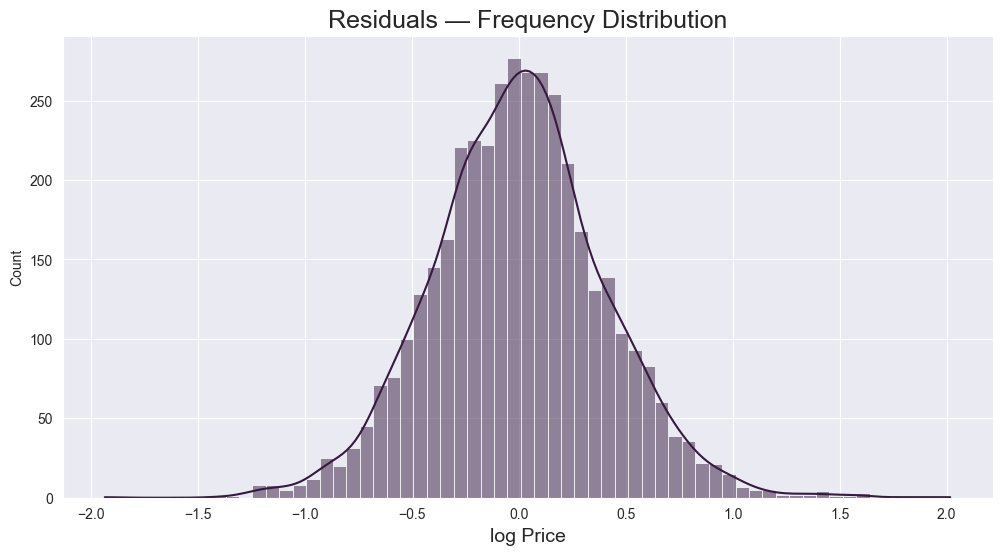

In [56]:
ax = sns.histplot(residuals, kde=True)
ax.figure.set_size_inches(12, 6)
ax.set_title('Residuals — Frequency Distribution', fontsize=18)
ax.set_xlabel('log Price', fontsize=14)
ax

<div style='background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 30px; border-radius: 10px; margin-top: 20px;'>
  <h2 style='color: #e94560; font-size: 28px; margin-bottom: 16px;'>Key Findings & Conclusions</h2>
  <ul style='color: #ccc; font-size: 17px; line-height: 2.2;'>
    <li>A <b style='color:#a8dadc;'>log-linear regression model</b> was successfully applied to predict real estate prices in Rio de Janeiro.</li>
    <li>The raw price distribution was <b style='color:#a8dadc;'>right-skewed</b>; log transformation approximated normality and improved model fit.</li>
    <li>The variable <b style='color:#a8dadc;'>Distance to the Pharmacy</b> was dropped after the statistical summary showed it was not statistically significant.</li>
    <li>The final model uses <b style='color:#a8dadc;'>Area</b> and <b style='color:#a8dadc;'>Distance to the Beach</b> as predictors, both highly significant (p &lt; 0.001).</li>
    <li>The model achieves an <b style='color:#a8dadc;'>R² ≈ 0.73</b> on both train and test sets, indicating good generalization with no signs of overfitting.</li>
    <li>Elasticity interpretation: every 1% increase in area raises price by ~<b style='color:#a8dadc;'>1.06%</b>; every 1% increase in beach distance lowers price by ~<b style='color:#a8dadc;'>0.49%</b>.</li>
  </ul>
</div>